>>> BẮT ĐẦU TẠO 16 TẬP CON VÀ KIỂM TRA PHÂN PHỐI:
Dataset 40.0/60: Đã tạo xong feature_train, label_train, feature_test, label_test.
Dataset 60.0/40: Đã tạo xong feature_train, label_train, feature_test, label_test.
Dataset 80.0/20: Đã tạo xong feature_train, label_train, feature_test, label_test.
Dataset 90.0/10: Đã tạo xong feature_train, label_train, feature_test, label_test.


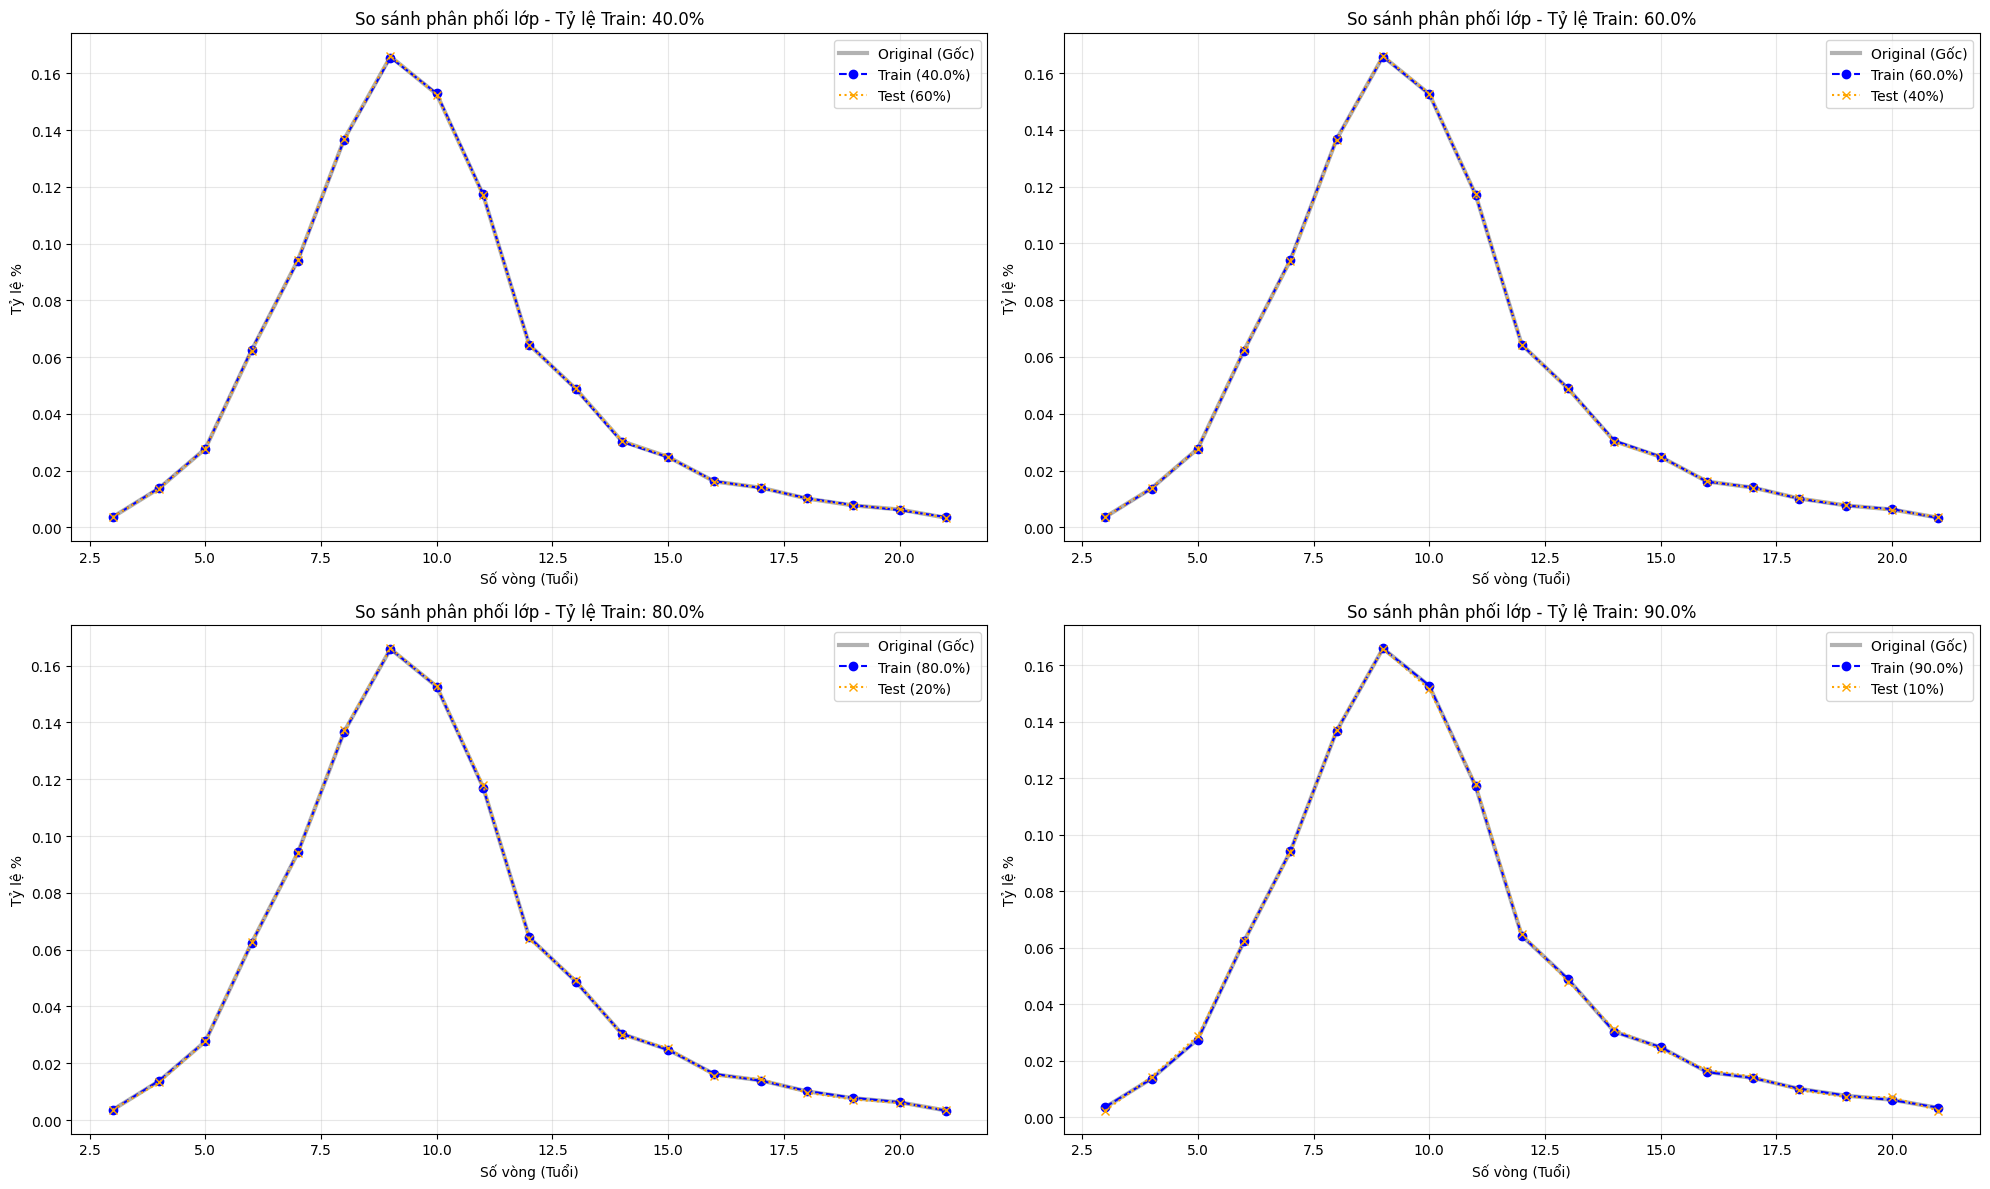

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ======================================================
# TIÊU CHÍ 1 (CẬP NHẬT): CHUẨN BỊ DỮ LIỆU & TRỰC QUAN HÓA
# ======================================================

# 1. Tải và Sơ chế dữ liệu
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
col_names = ["Sex", "Length", "Diameter", "Height", "Whole_weight", 
             "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"]
df = pd.read_csv(url, header=None, names=col_names)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['Sex'], drop_first=False)

# Lọc lớp hiếm (để đảm bảo Stratify hoạt động được)
class_counts = df['Rings'].value_counts()
valid_rings = class_counts[class_counts >= 10].index
df_clean = df[df['Rings'].isin(valid_rings)].copy()

X = df_clean.drop('Rings', axis=1)
y = df_clean['Rings']

# --- KIỂM TRA YÊU CẦU ĐỀ BÀI ---
# Yêu cầu: 4 tỷ lệ chia (40/60, 60/40, 80/20, 90/10)
ratios = [0.4, 0.6, 0.8, 0.9]

# Tạo khung hình vẽ lớn
plt.figure(figsize=(20, 12)) 

# Tính phân phối của TẬP GỐC (Để so sánh)
original_dist = y.value_counts(normalize=True).sort_index()

print(">>> BẮT ĐẦU TẠO 16 TẬP CON VÀ KIỂM TRA PHÂN PHỐI:")

for i, ratio in enumerate(ratios):
    # Yêu cầu: Shuffle=True (Xáo trộn), Stratify=y (Phân tầng)
    # Các tham số khác mặc định
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, stratify=y, shuffle=True, random_state=42
    )
    
    # Tính phân phối của Train và Test
    train_dist = y_train.value_counts(normalize=True).sort_index()
    test_dist = y_test.value_counts(normalize=True).sort_index()
    
    # --- VẼ BIỂU ĐỒ (VISUALIZATION) ---
    plt.subplot(2, 2, i+1)
    
    # Vẽ 3 đường: Gốc (Đen), Train (Xanh), Test (Cam)
    # Nếu 3 đường này chồng lên nhau -> ĐÃ CHỨNG MINH THÀNH CÔNG
    plt.plot(original_dist.index, original_dist.values, label='Original (Gốc)', color='black', linewidth=3, alpha=0.3)
    plt.plot(train_dist.index, train_dist.values, label=f'Train ({ratio*100}%)', color='blue', marker='o', linestyle='--')
    plt.plot(test_dist.index, test_dist.values, label=f'Test ({round((1-ratio)*100)}%)', color='orange', marker='x', linestyle=':')
    
    plt.title(f'So sánh phân phối lớp - Tỷ lệ Train: {ratio*100}%')
    plt.xlabel('Số vòng (Tuổi)')
    plt.ylabel('Tỷ lệ %')
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"Dataset {ratio*100}/{round((1-ratio)*100)}: Đã tạo xong feature_train, label_train, feature_test, label_test.")

plt.tight_layout()
plt.show()

>>> BẮT ĐẦU HUẤN LUYỆN VÀ VẼ CÂY CHO CẢ 4 TỶ LỆ
-> Đã huấn luyện xong mô hình tỷ lệ 40.0%
-> Đã huấn luyện xong mô hình tỷ lệ 60.0%
-> Đã huấn luyện xong mô hình tỷ lệ 80.0%
-> Đã huấn luyện xong mô hình tỷ lệ 90.0%

>>> ĐANG VẼ HÌNH CÂY QUYẾT ĐỊNH (SẼ HIỆN 4 HÌNH)...


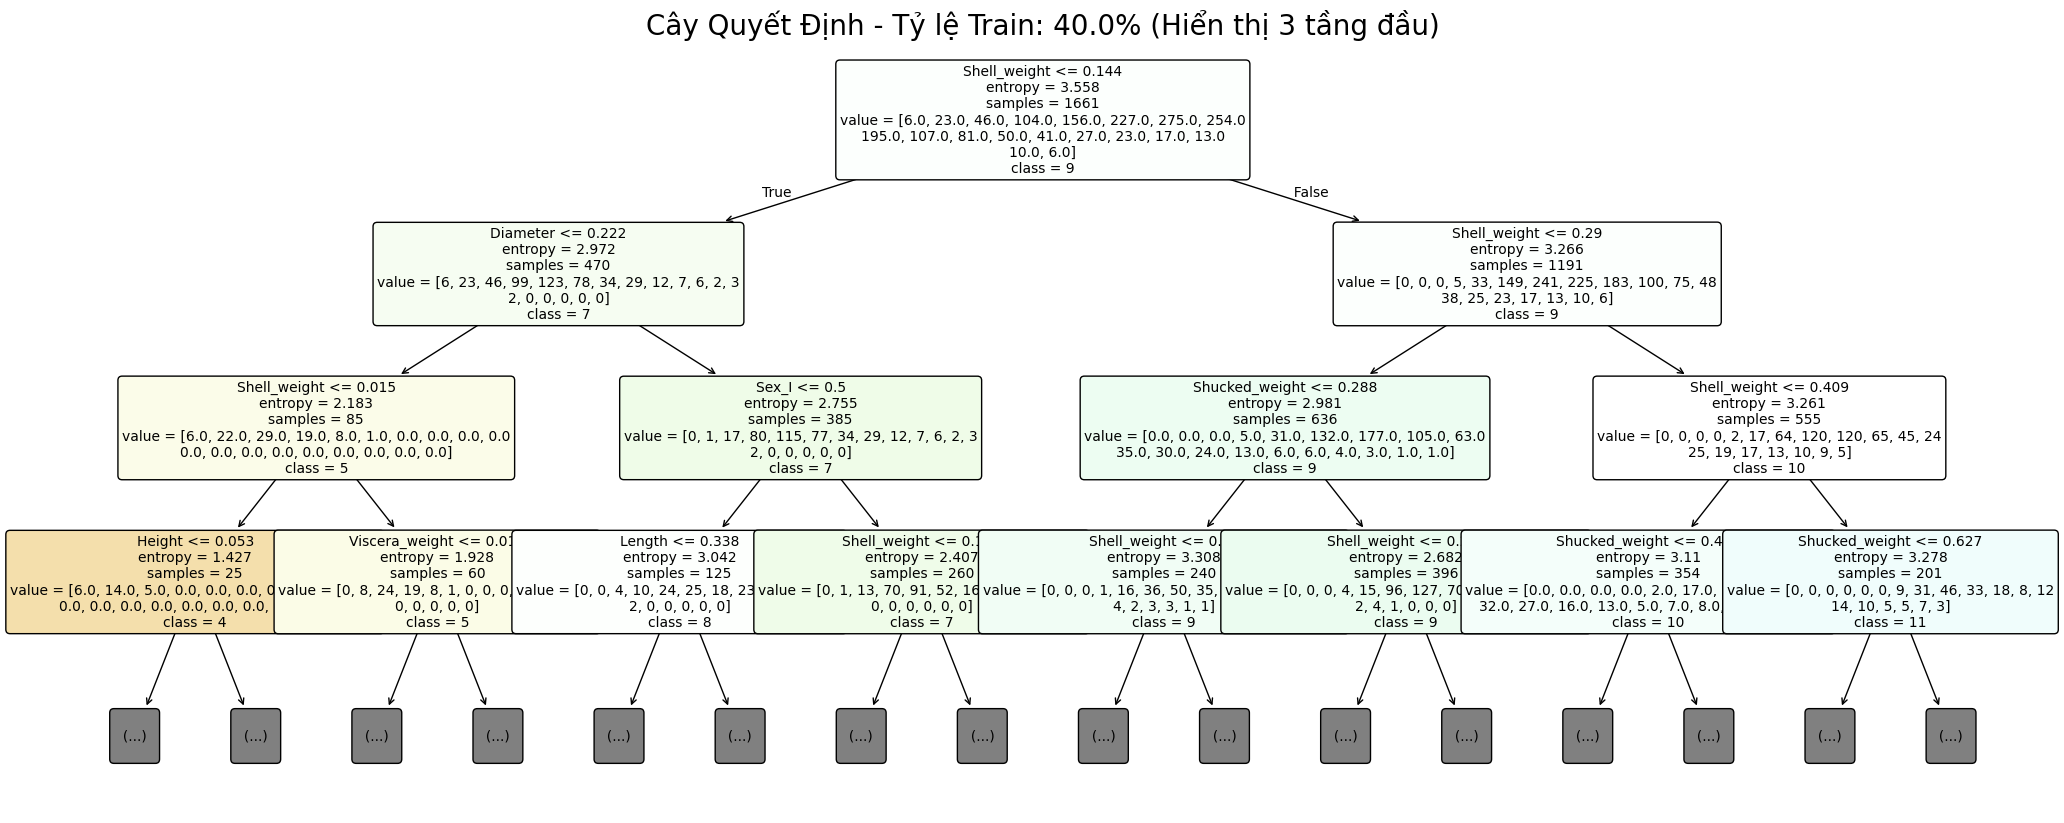

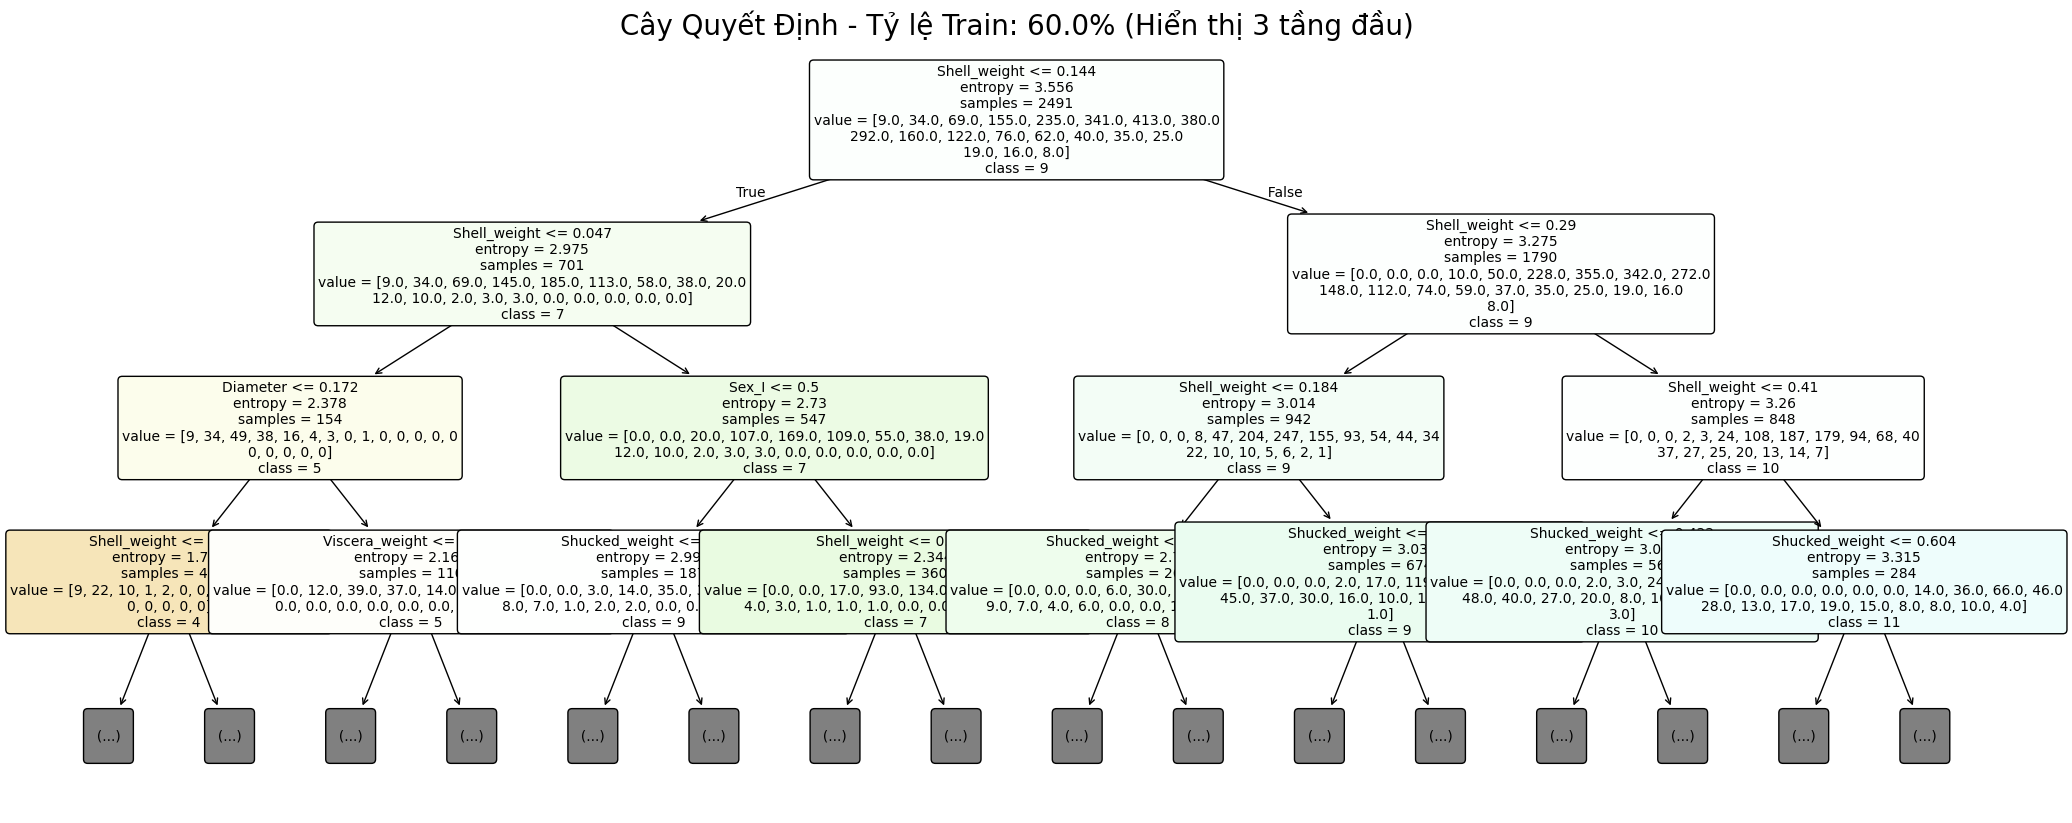

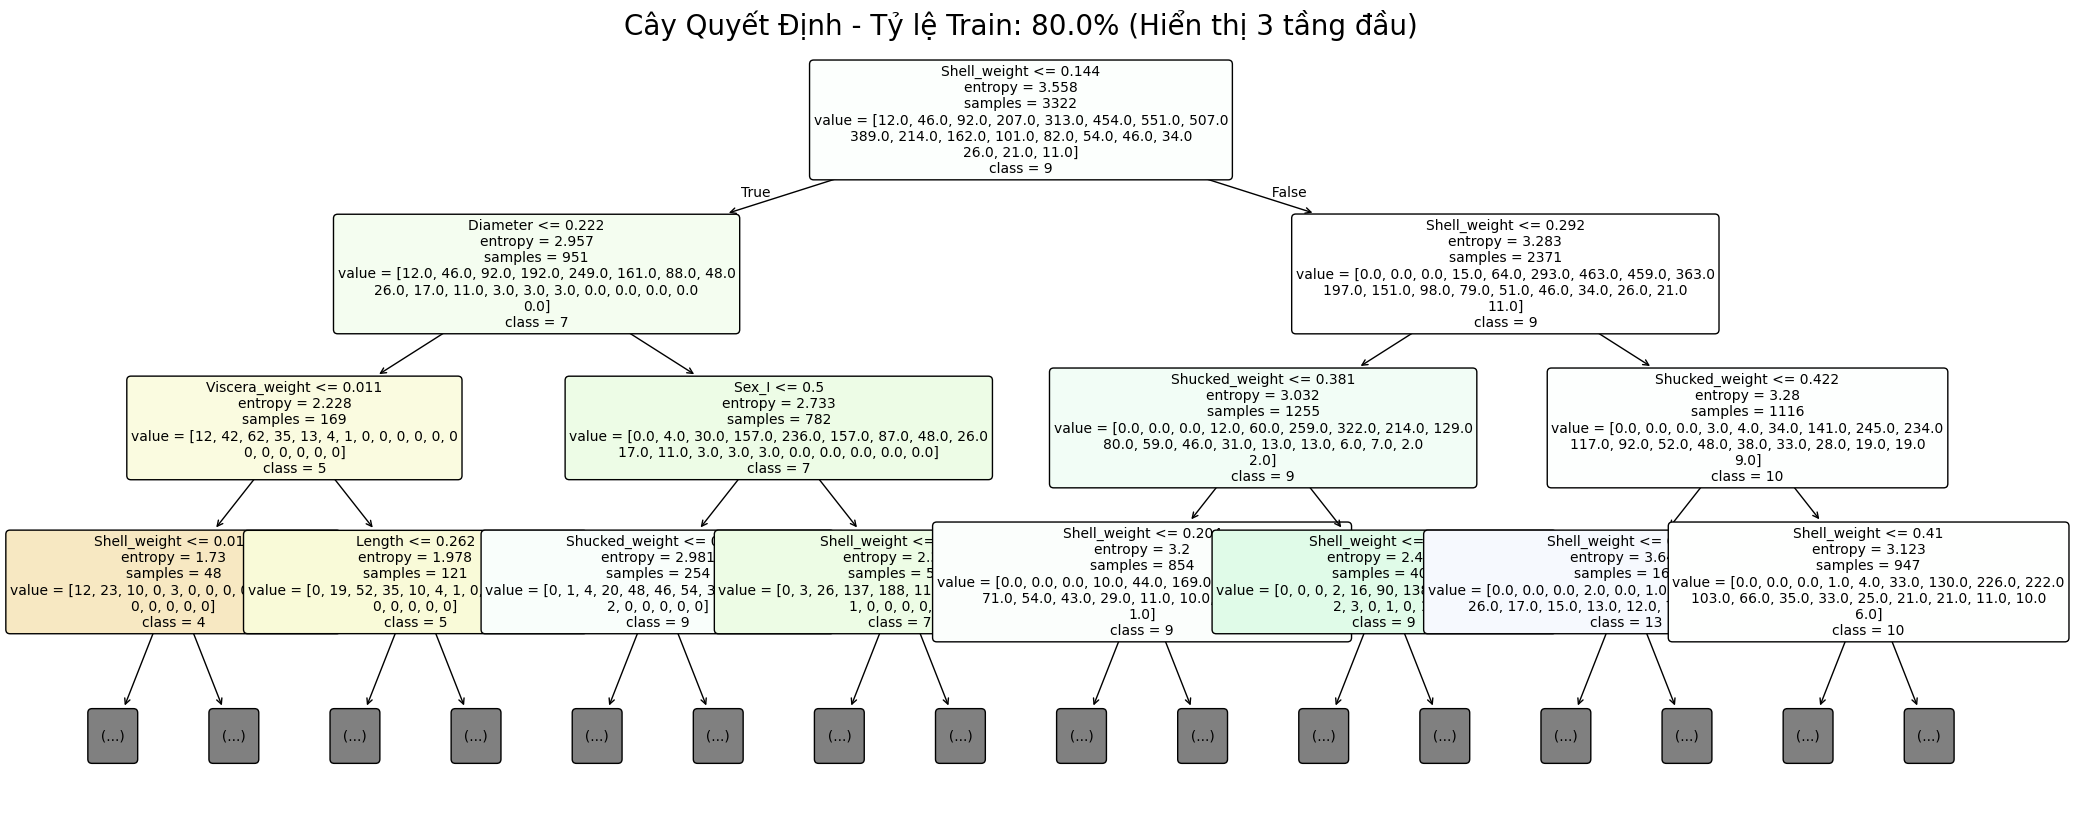

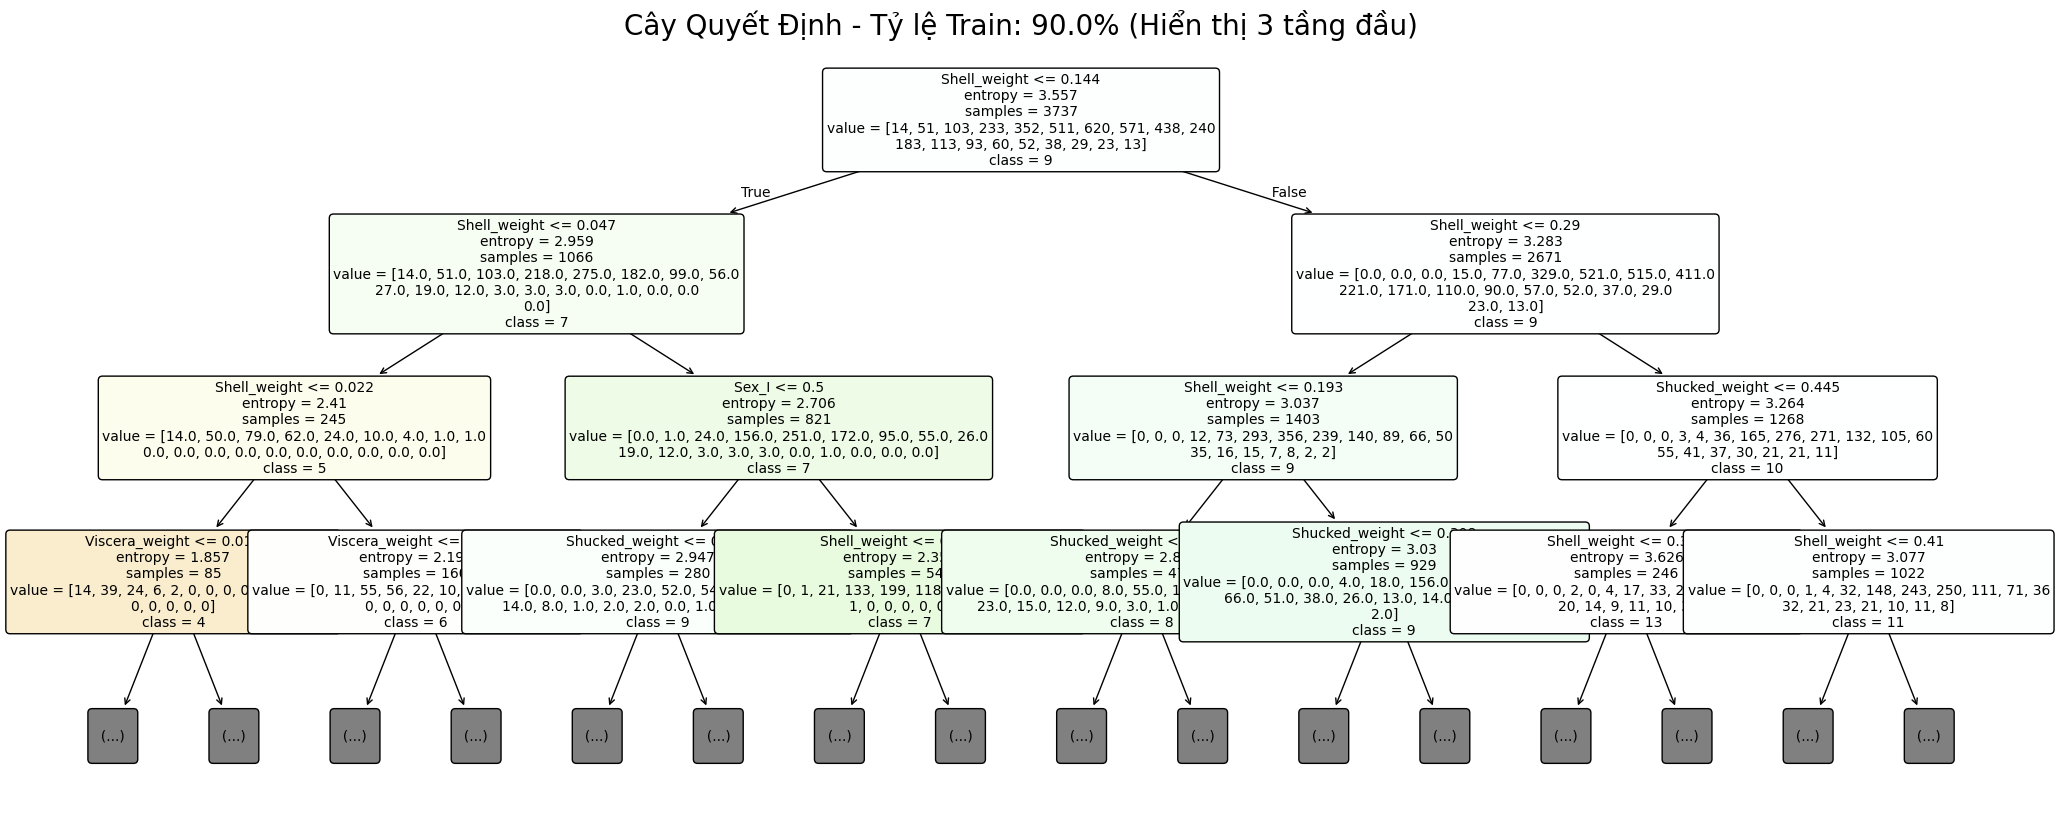

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ======================================================
# TIÊU CHÍ 2 (CẬP NHẬT): HUẤN LUYỆN VÀ VẼ ĐỦ 4 CÂY
# ======================================================

print(">>> BẮT ĐẦU HUẤN LUYỆN VÀ VẼ CÂY CHO CẢ 4 TỶ LỆ")

# Danh sách tỷ lệ
ratios = [0.4, 0.6, 0.8, 0.9]
models = {} 

# --- BƯỚC 1: HUẤN LUYỆN (TRAINING) ---
for ratio in ratios:
    # Chia dữ liệu
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, stratify=y, random_state=42
    )
    
    # Tạo và huấn luyện mô hình (criterion='entropy')
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    
    # Lưu lại để dùng sau
    models[ratio] = {'model': clf, 'X_test': X_test, 'y_test': y_test}
    print(f"-> Đã huấn luyện xong mô hình tỷ lệ {ratio*100}%")

# --- BƯỚC 2: TRỰC QUAN HÓA (VẼ 4 CÂY) ---
print("\n>>> ĐANG VẼ HÌNH CÂY QUYẾT ĐỊNH (SẼ HIỆN 4 HÌNH)...")

for ratio in ratios:
    clf = models[ratio]['model']
    
    # Tạo khung hình riêng cho mỗi cây
    plt.figure(figsize=(25, 10)) 
    
    # Vẽ cây
    # Lưu ý: Vẫn giữ max_depth=3 để hình vẽ dễ nhìn, không bị rối rắm
    plot_tree(clf, 
              feature_names=X.columns, 
              class_names=[str(c) for c in clf.classes_],
              filled=True, 
              rounded=True, 
              max_depth=3, # Chỉ hiển thị 3 tầng đầu (Gốc)
              fontsize=10)
    
    plt.title(f"Cây Quyết Định - Tỷ lệ Train: {ratio*100}% (Hiển thị 3 tầng đầu)", fontsize=20)
    plt.show() # In hình ra ngay lập tức

>>> BẮT ĐẦU ĐÁNH GIÁ TOÀN DIỆN 4 TỶ LỆ DỮ LIỆU

############################################################
TRƯỜNG HỢP: TRAIN 40% - TEST 60%
############################################################

1. Bảng báo cáo phân lớp (Classification Report):
              precision    recall  f1-score   support

           3       0.25      0.22      0.24         9
           4       0.31      0.32      0.32        34
           5       0.24      0.26      0.25        69
           6       0.24      0.23      0.23       155
           7       0.26      0.26      0.26       235
           8       0.24      0.23      0.23       341
           9       0.20      0.20      0.20       414
          10       0.23      0.23      0.23       380
          11       0.20      0.22      0.21       292
          12       0.12      0.12      0.12       160
          13       0.11      0.11      0.11       122
          14       0.04      0.04      0.04        76
          15       0.06      0.05      0.05

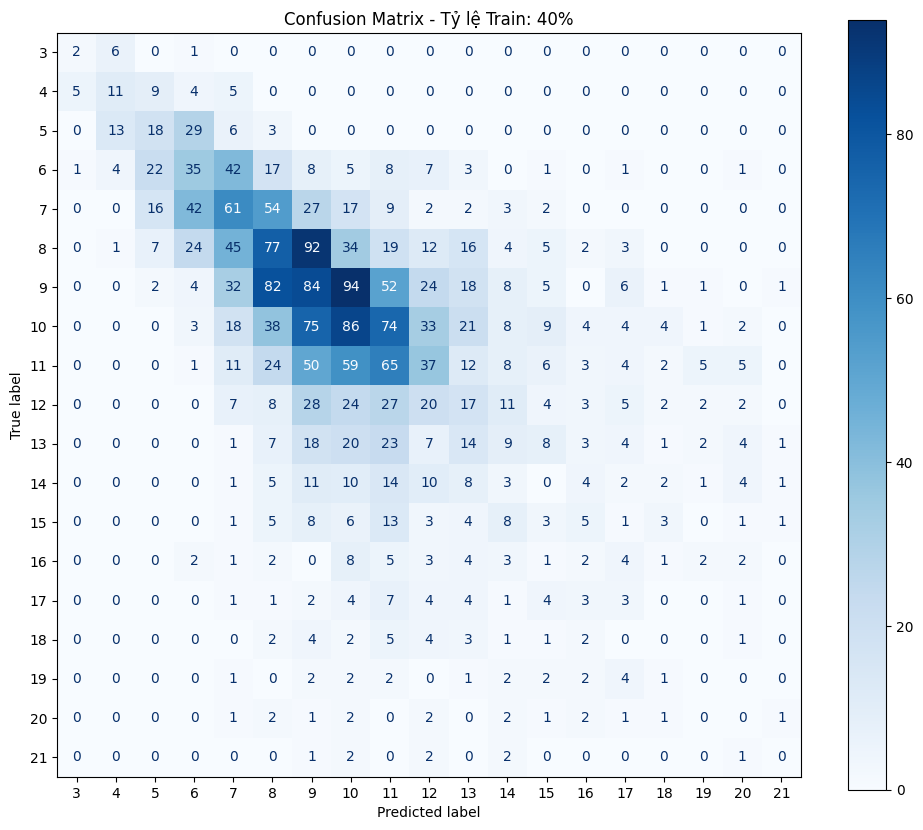


############################################################
TRƯỜNG HỢP: TRAIN 60% - TEST 40%
############################################################

1. Bảng báo cáo phân lớp (Classification Report):
              precision    recall  f1-score   support

           3       0.14      0.17      0.15         6
           4       0.29      0.30      0.30        23
           5       0.42      0.43      0.43        46
           6       0.26      0.25      0.25       104
           7       0.25      0.24      0.25       156
           8       0.27      0.27      0.27       227
           9       0.24      0.25      0.25       276
          10       0.24      0.25      0.25       254
          11       0.20      0.21      0.20       195
          12       0.12      0.12      0.12       107
          13       0.12      0.12      0.12        81
          14       0.05      0.04      0.04        50
          15       0.10      0.07      0.08        41
          16       0.03      0.04   

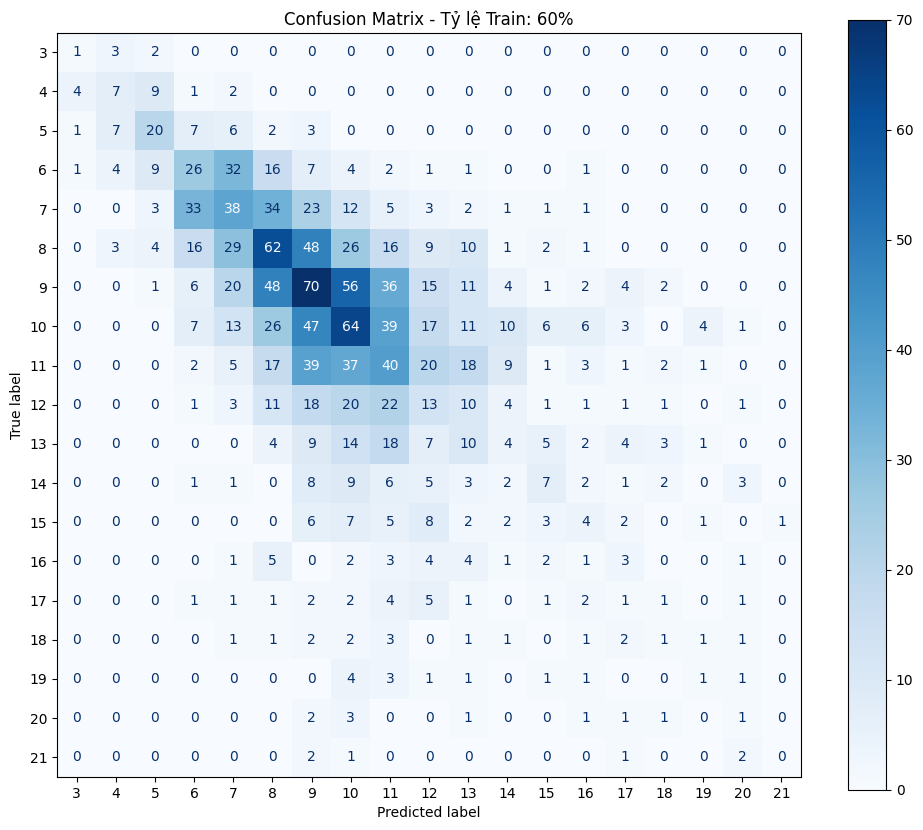


############################################################
TRƯỜNG HỢP: TRAIN 80% - TEST 20%
############################################################

1. Bảng báo cáo phân lớp (Classification Report):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.25      0.18      0.21        11
           5       0.13      0.13      0.13        23
           6       0.24      0.23      0.24        52
           7       0.28      0.32      0.30        78
           8       0.18      0.18      0.18       114
           9       0.21      0.22      0.22       138
          10       0.23      0.21      0.22       127
          11       0.19      0.20      0.20        98
          12       0.17      0.15      0.16        53
          13       0.10      0.12      0.11        41
          14       0.04      0.04      0.04        25
          15       0.25      0.14      0.18        21
          16       0.00      0.00   

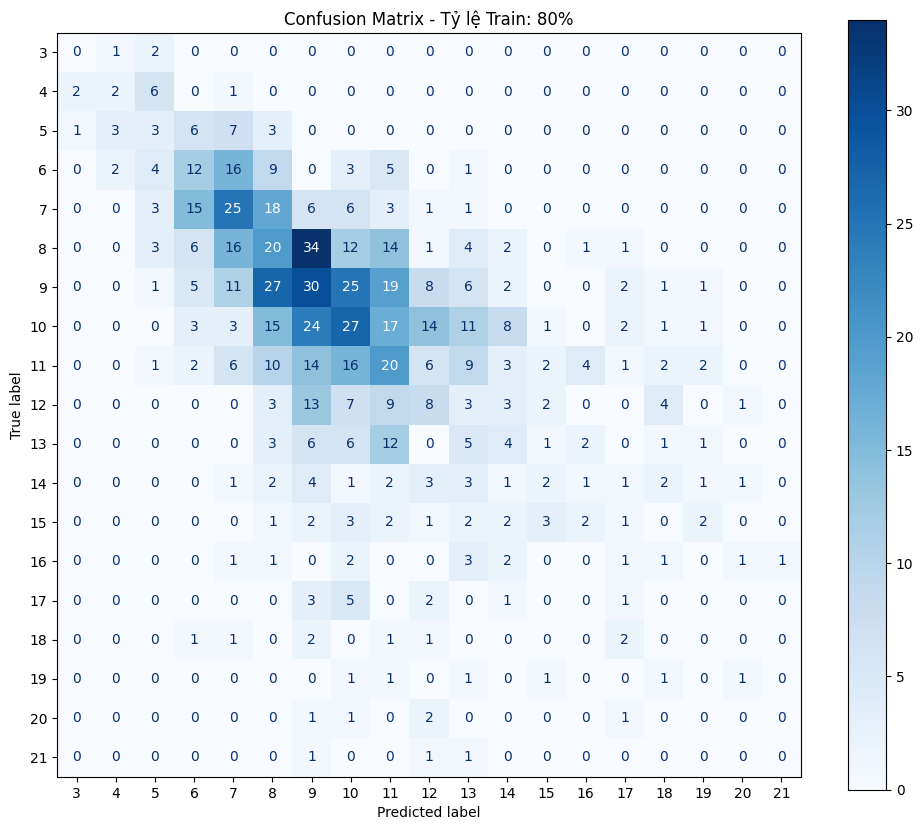


############################################################
TRƯỜNG HỢP: TRAIN 90% - TEST 10%
############################################################

1. Bảng báo cáo phân lớp (Classification Report):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.57      0.67      0.62         6
           5       0.29      0.17      0.21        12
           6       0.23      0.23      0.23        26
           7       0.19      0.15      0.17        39
           8       0.23      0.28      0.25        57
           9       0.24      0.25      0.24        69
          10       0.23      0.25      0.24        63
          11       0.17      0.16      0.17        49
          12       0.11      0.07      0.09        27
          13       0.14      0.15      0.15        20
          14       0.18      0.15      0.17        13
          15       0.00      0.00      0.00        10
          16       0.00      0.00   

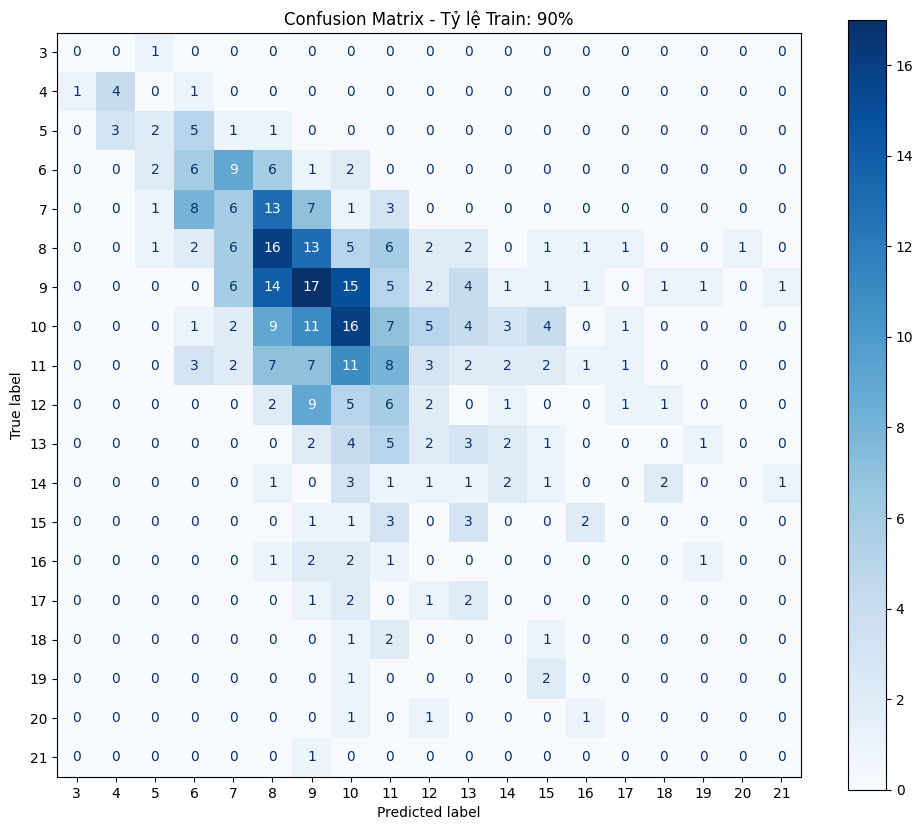

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# ======================================================
# TIÊU CHÍ 3 (FULL): BÁO CÁO & MA TRẬN CHO CẢ 4 TRƯỜNG HỢP
# ======================================================

print(">>> BẮT ĐẦU ĐÁNH GIÁ TOÀN DIỆN 4 TỶ LỆ DỮ LIỆU")

# Danh sách tỷ lệ
ratios = [0.4, 0.6, 0.8, 0.9]

for ratio in ratios:
    print("\n" + "#"*60)
    print(f"TRƯỜNG HỢP: TRAIN {round(ratio*100)}% - TEST {round((1-ratio)*100)}%")
    print("#"*60)
    
    # 1. Chia dữ liệu (Làm lại để đảm bảo đúng khớp từng vòng lặp)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, stratify=y, random_state=42
    )
    
    # 2. Huấn luyện (Train)
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    
    # 3. Dự đoán (Predict)
    y_pred = clf.predict(X_test)
    
    # 4. In Bảng báo cáo phân lớp (Classification Report)
    print("\n1. Bảng báo cáo phân lớp (Classification Report):")
    # zero_division=0 để tránh báo lỗi với các lớp không đoán được
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # 5. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
    print("2. Ma trận nhầm lẫn (Confusion Matrix):")
    fig, ax = plt.subplots(figsize=(12, 10))
    # Dùng cmap='Greens' cho đổi gió, hoặc 'Blues' tùy bạn thích
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Blues', ax=ax)
    plt.title(f"Confusion Matrix - Tỷ lệ Train: {int(ratio*100)}%")
    plt.show()

>>> BẮT ĐẦU KHẢO SÁT VÀ VẼ CÂY (CHẾ ĐỘ CO GIÃN THÔNG MINH)...

[2] Đang vẽ cây... (Độ chính xác: 23.35%)


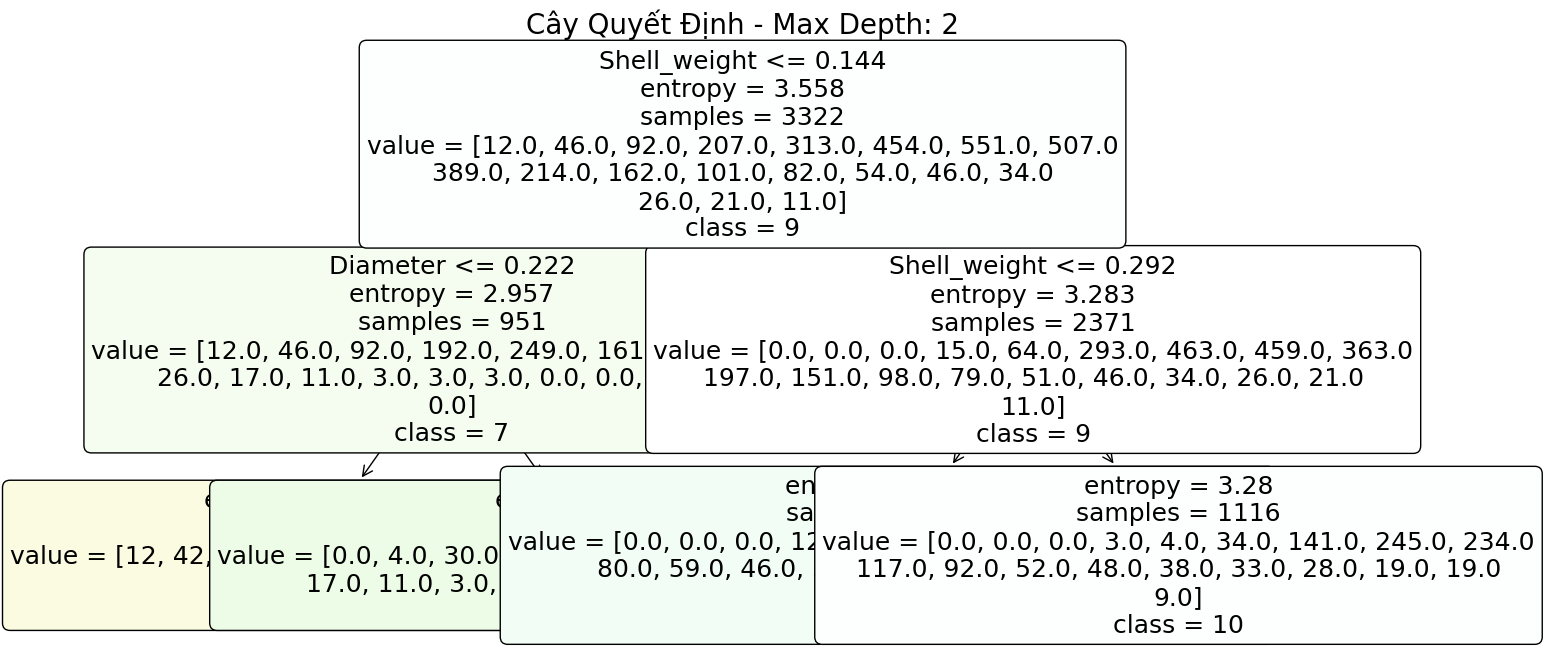


[3] Đang vẽ cây... (Độ chính xác: 23.83%)


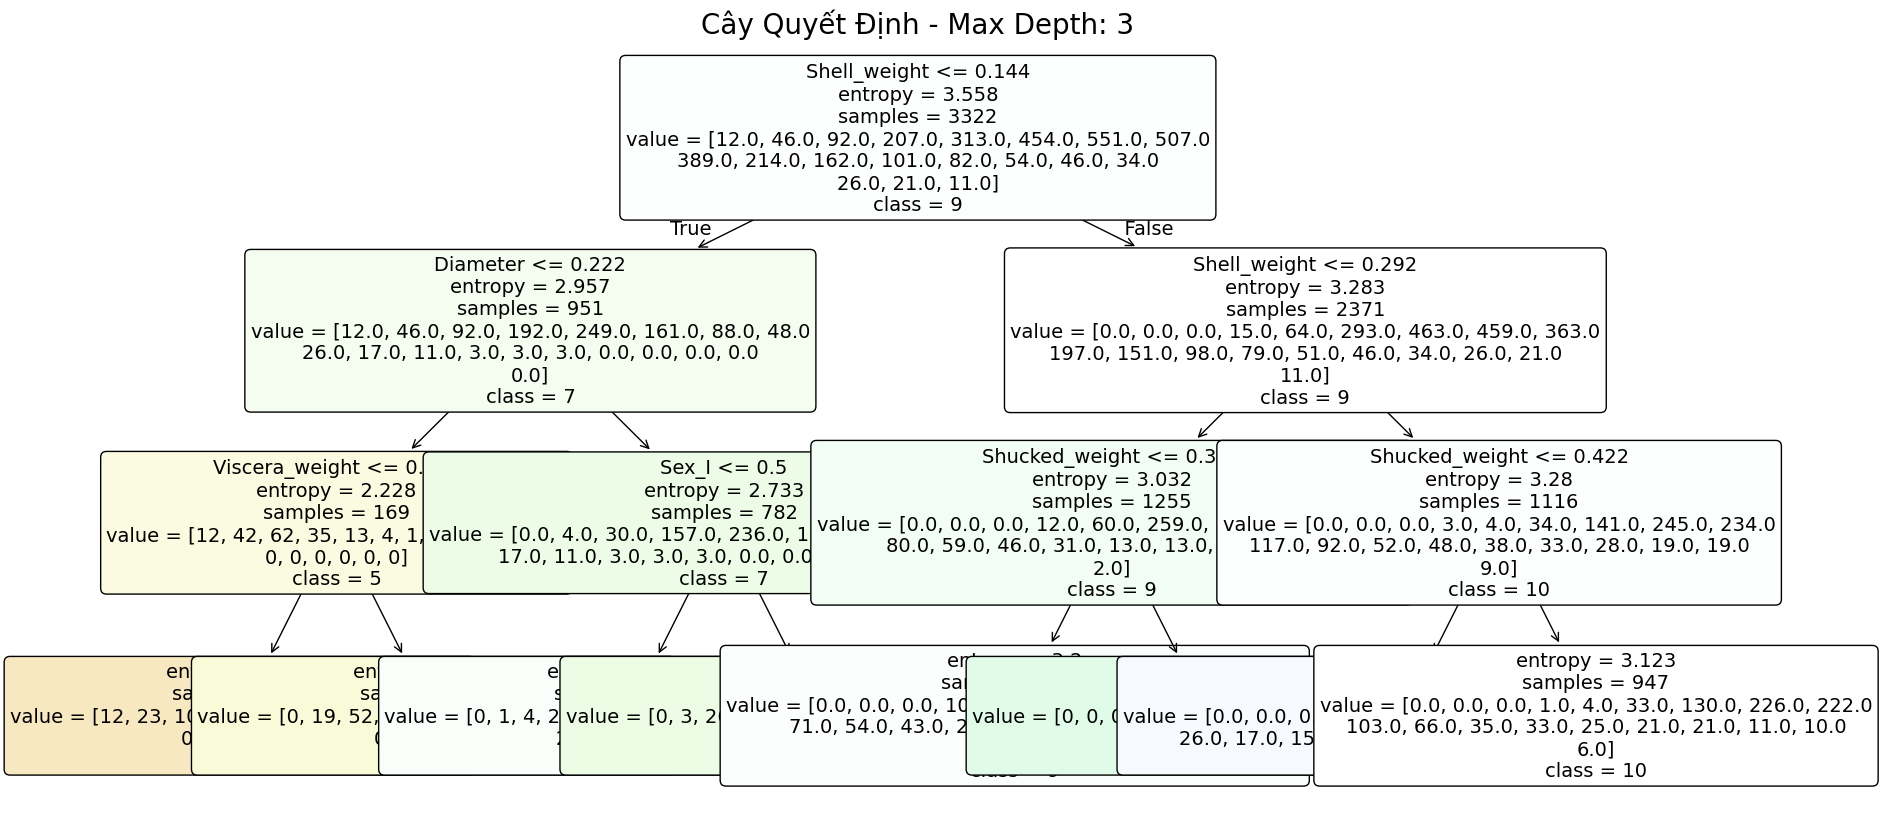


[4] Đang vẽ cây... (Độ chính xác: 25.39%)


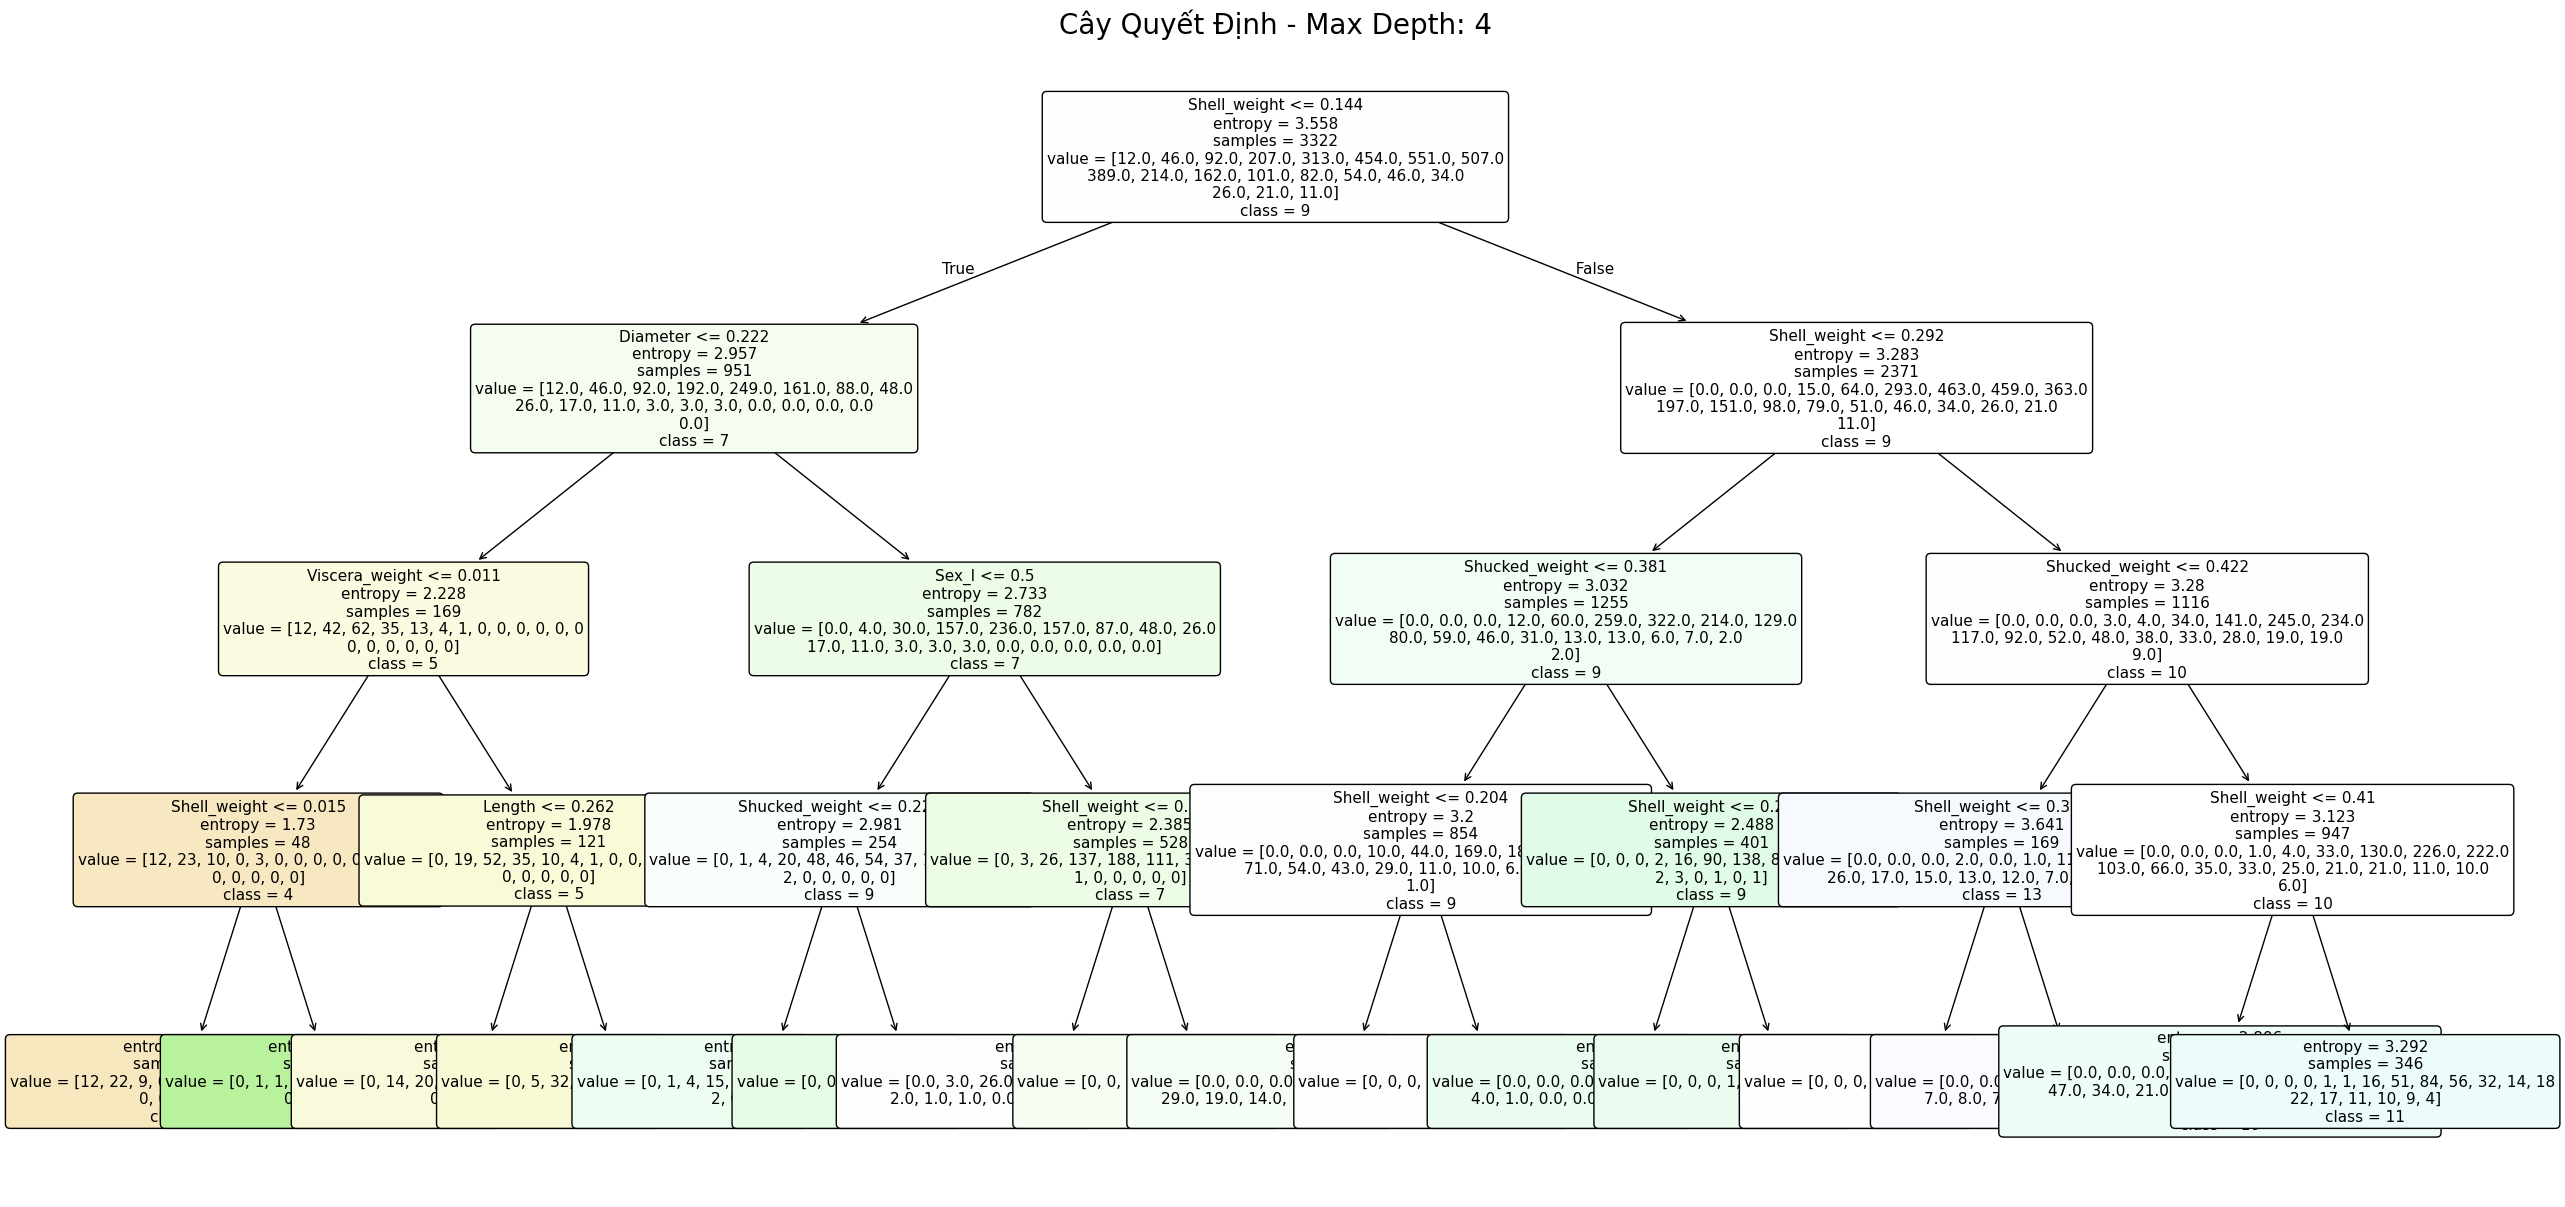


[5] Đang vẽ cây... (Độ chính xác: 23.35%)


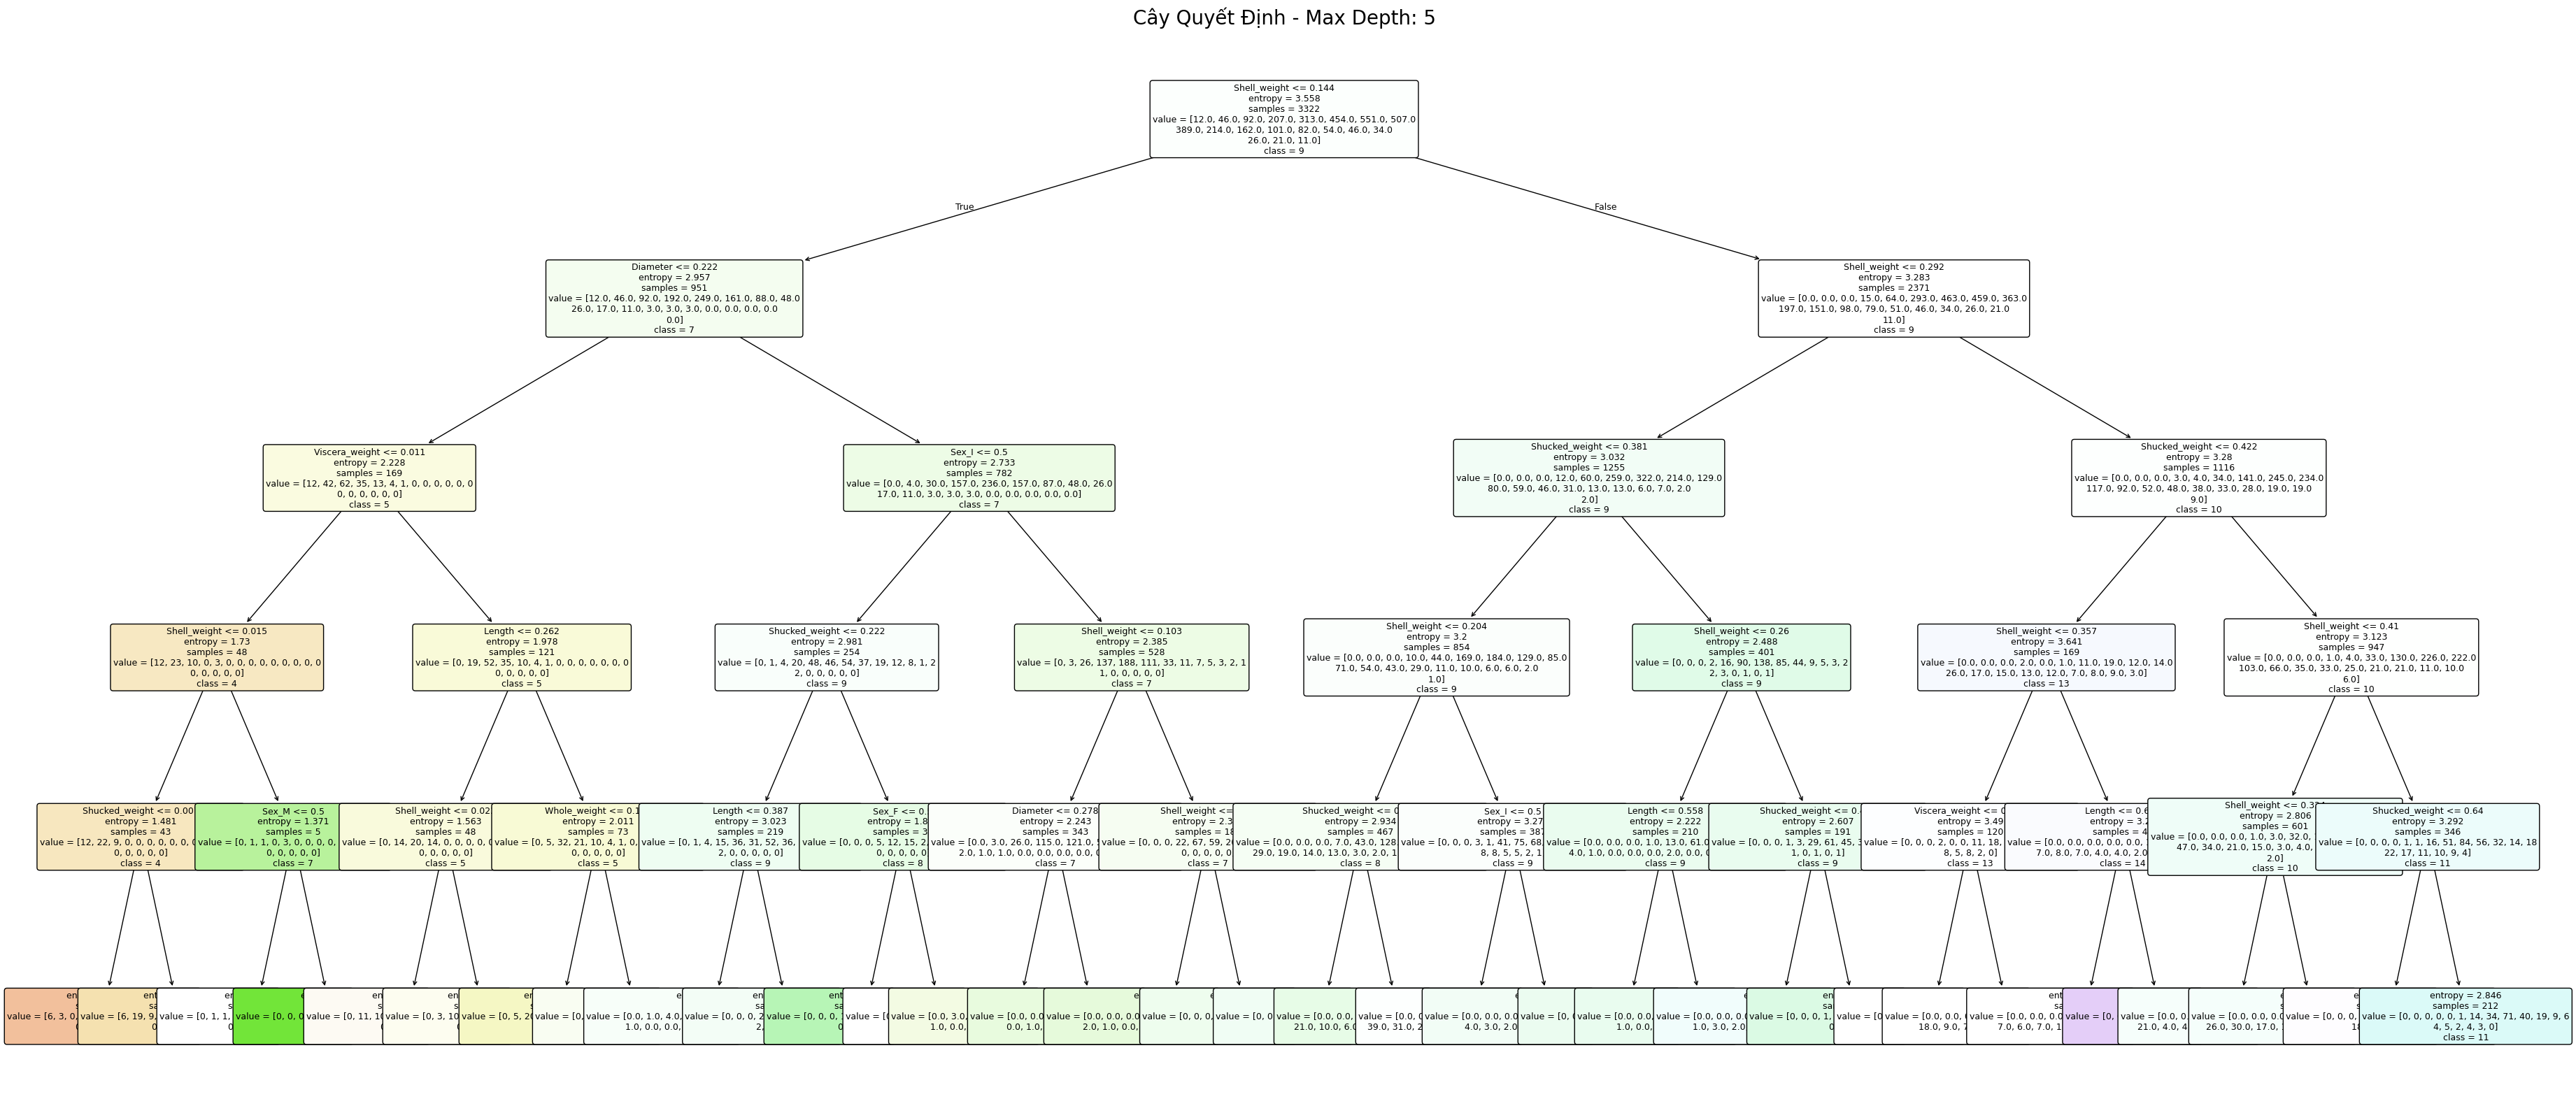


[6] Đang vẽ cây... (Độ chính xác: 24.91%)


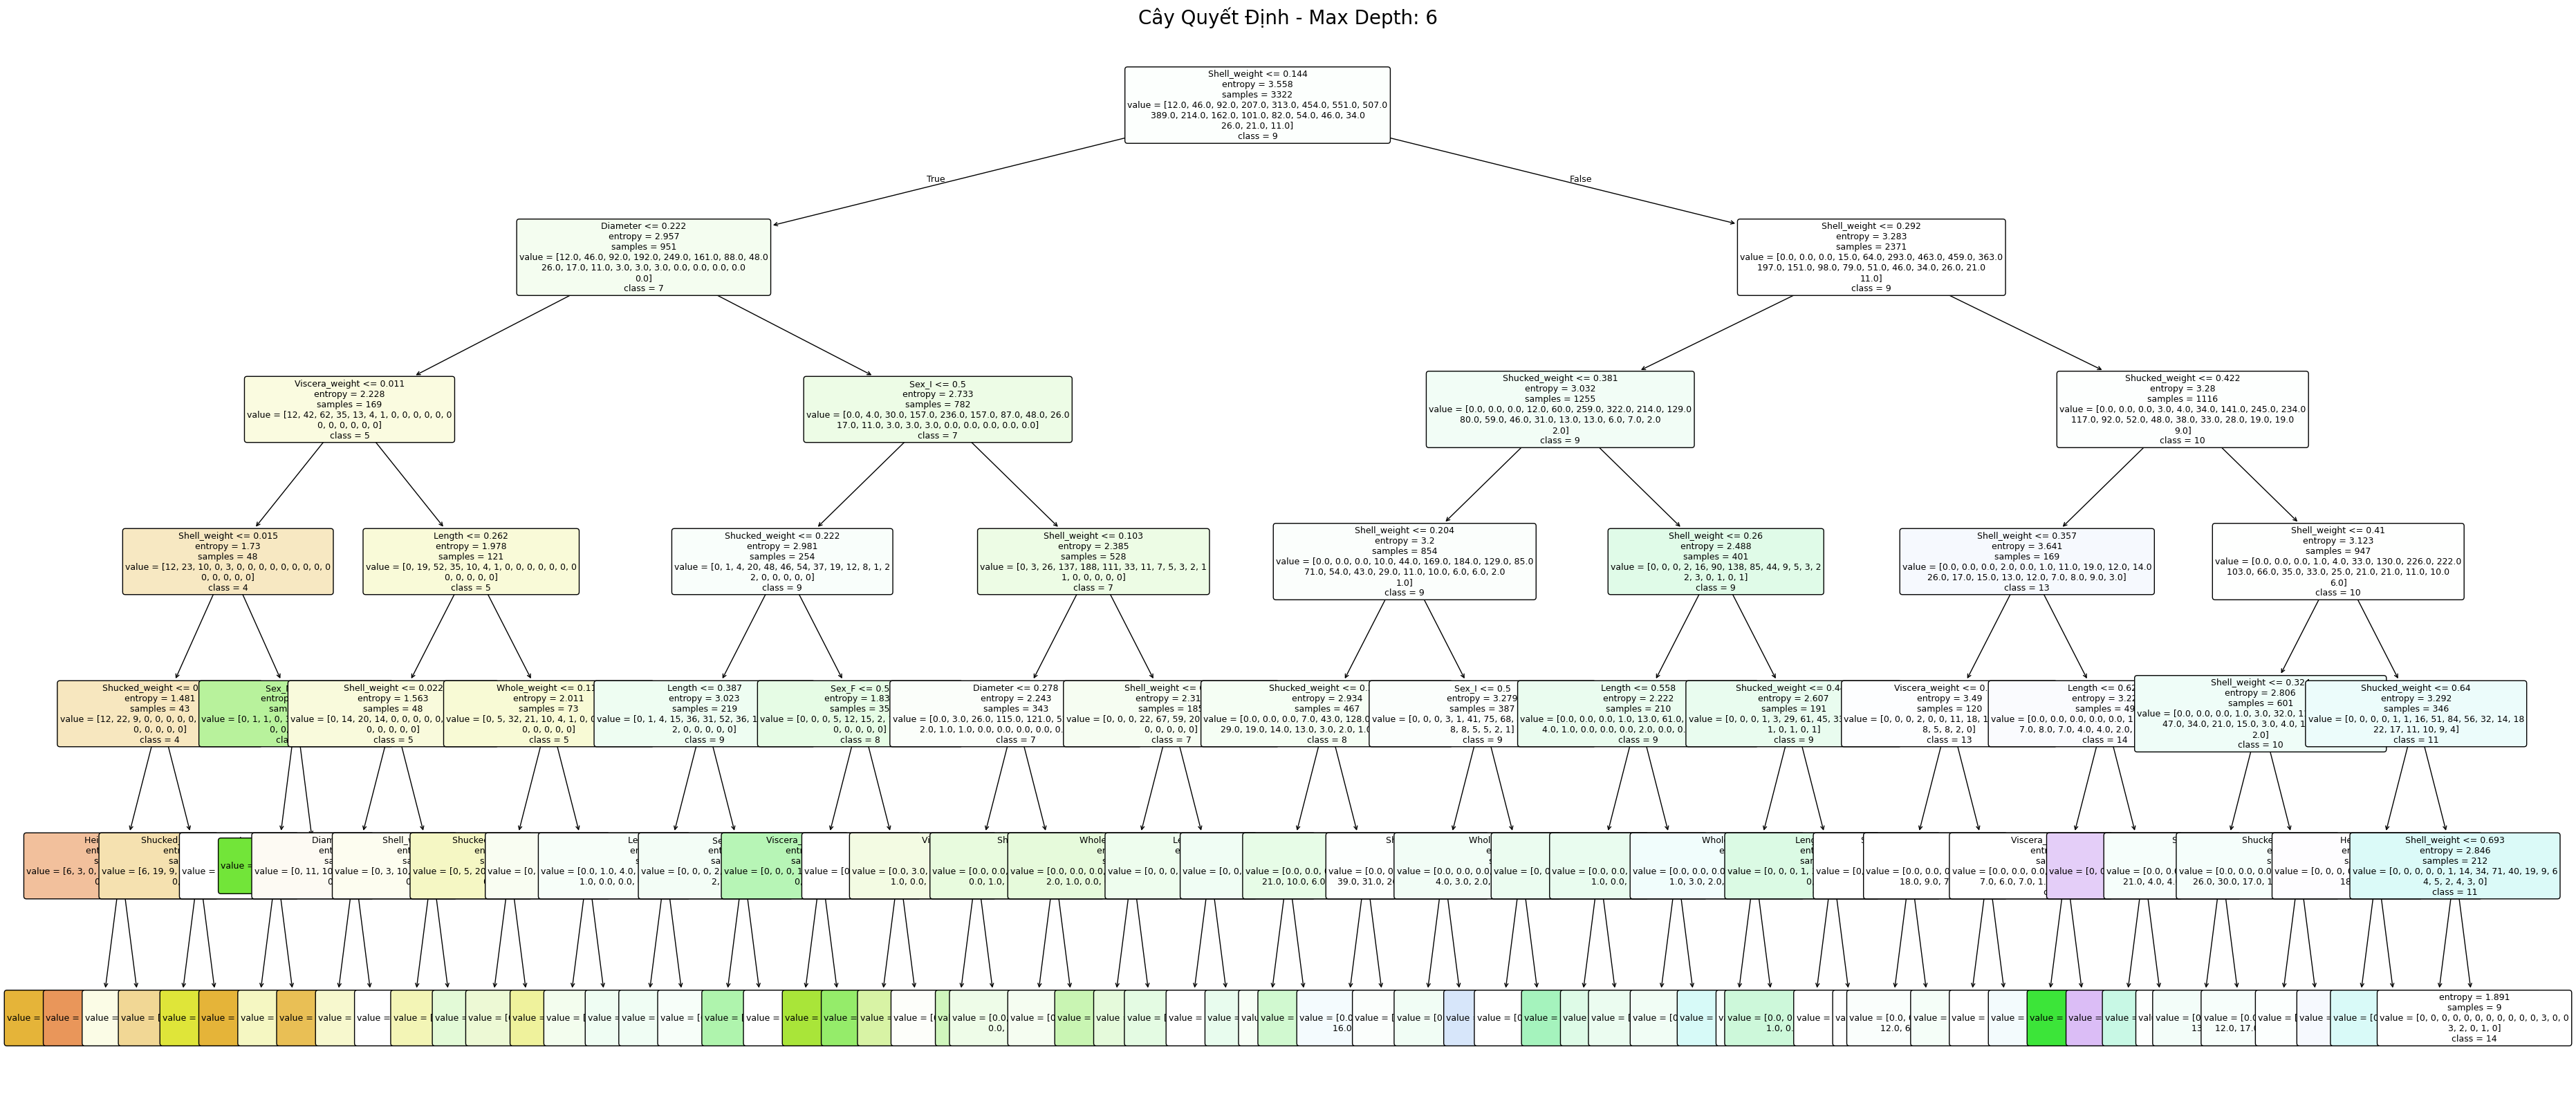


[7] Đang vẽ cây... (Độ chính xác: 23.71%)


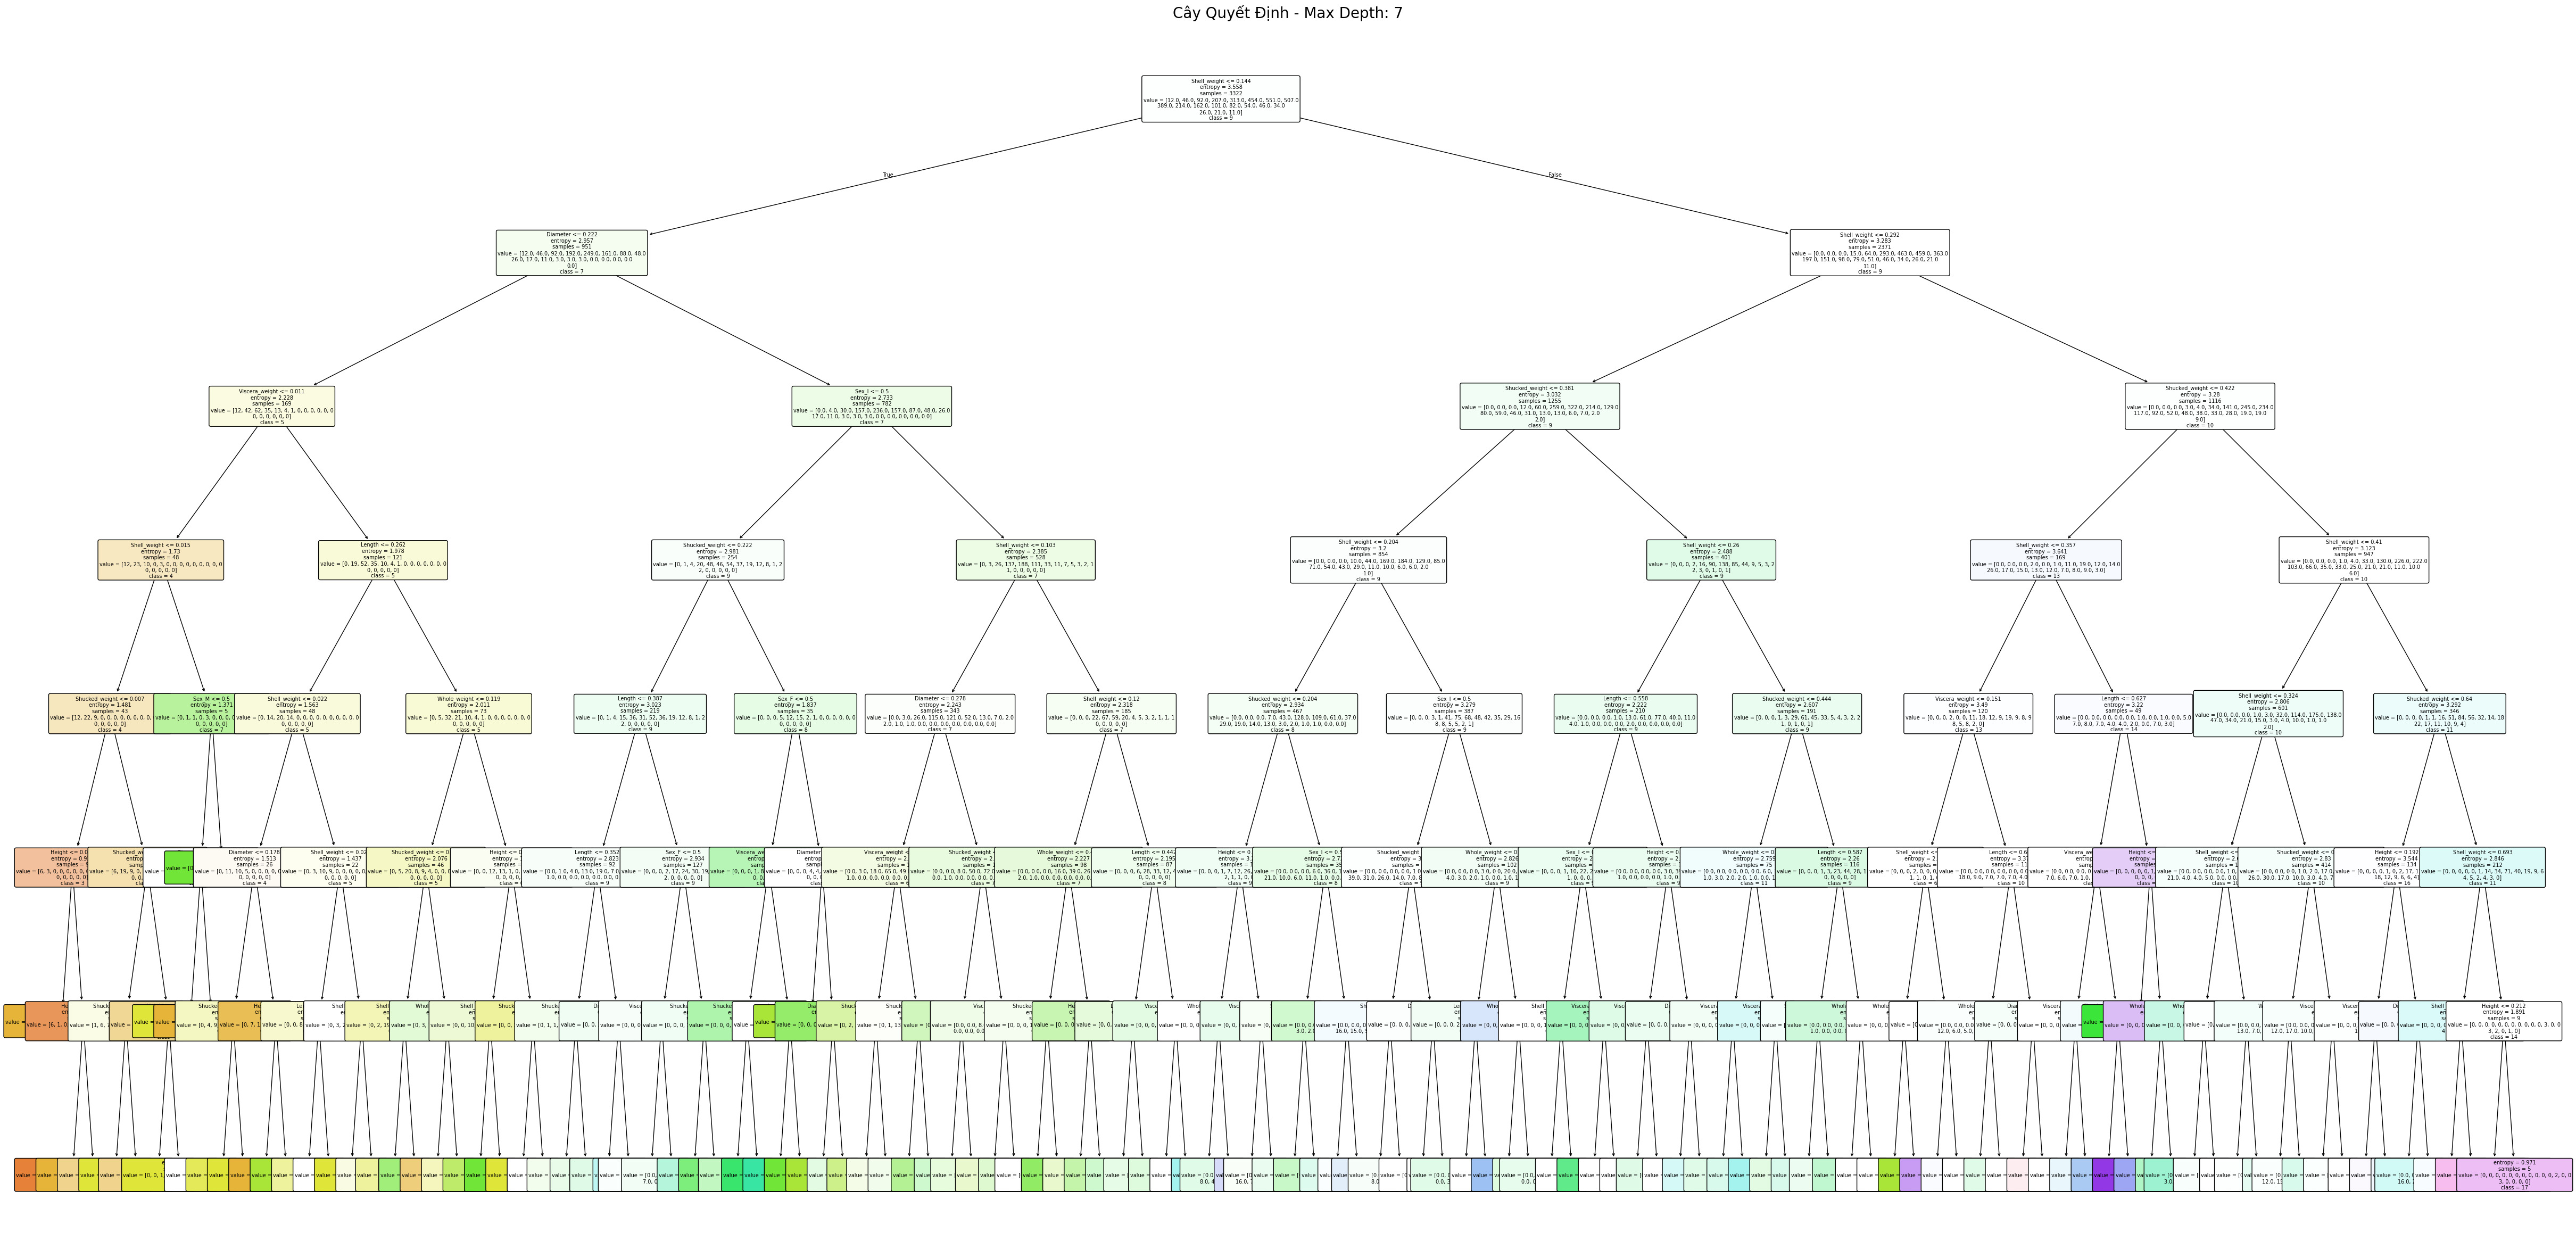


[None (Max)] Đang vẽ cây... (Độ chính xác: 18.89%)


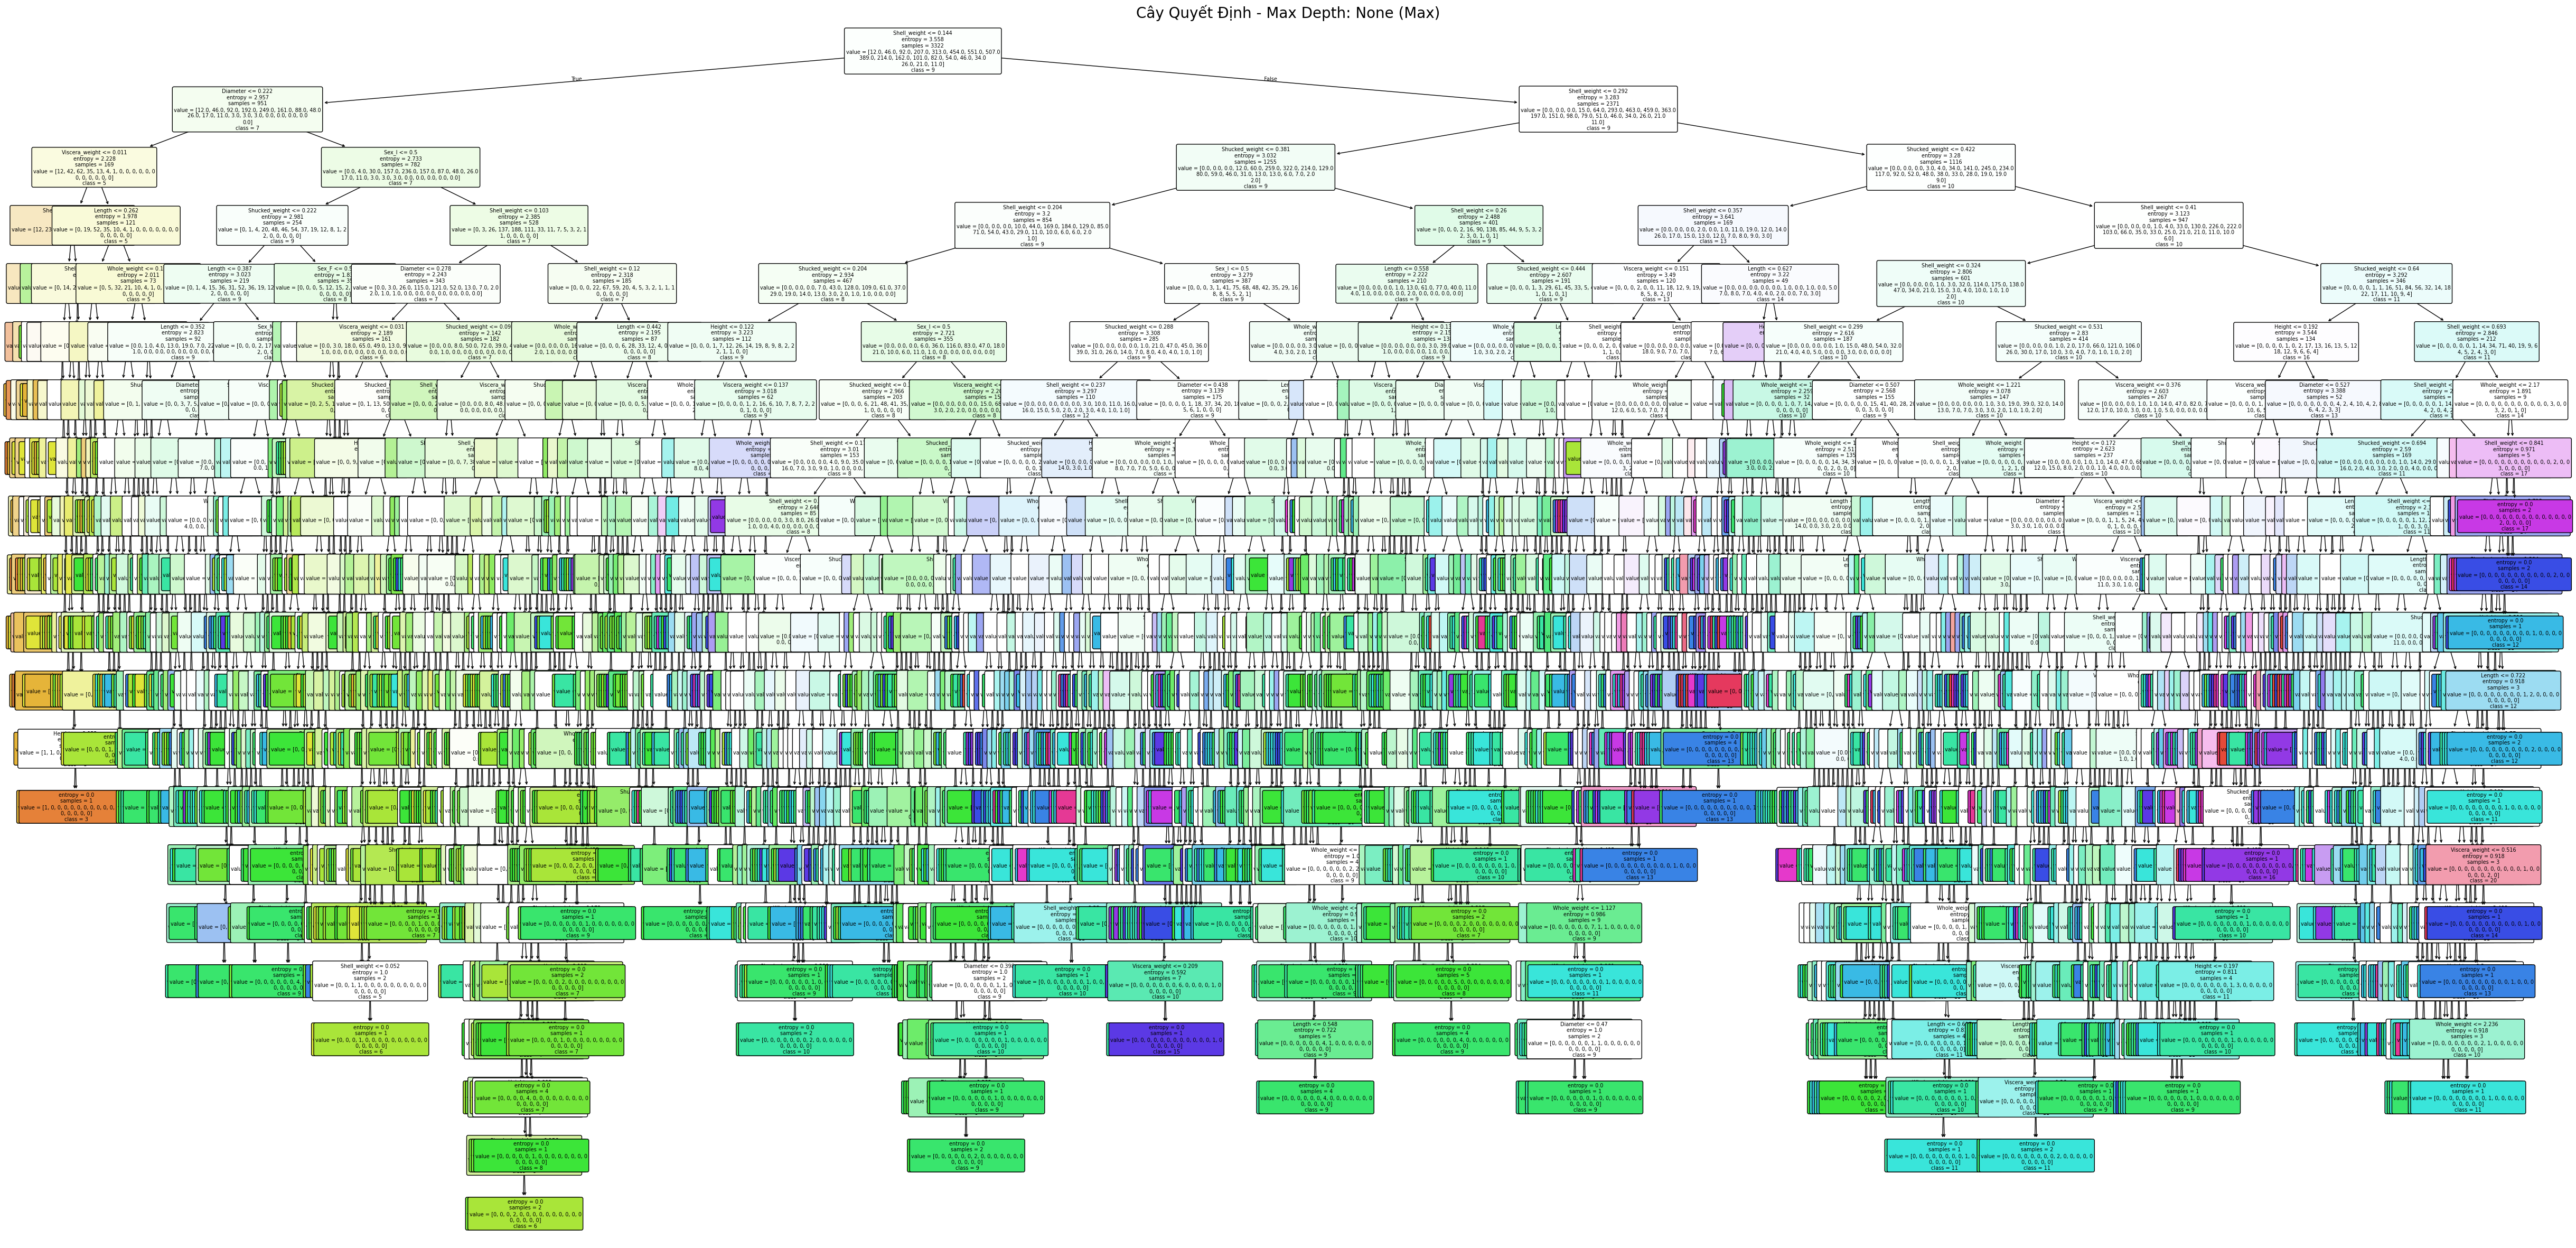


BẢNG KẾT QUẢ ĐỘ CHÍNH XÁC
    Max Depth  Accuracy
0           2  0.233454
1           3  0.238267
2           4  0.253911
3           5  0.233454
4           6  0.249097
5           7  0.237064
6  None (Max)  0.188929


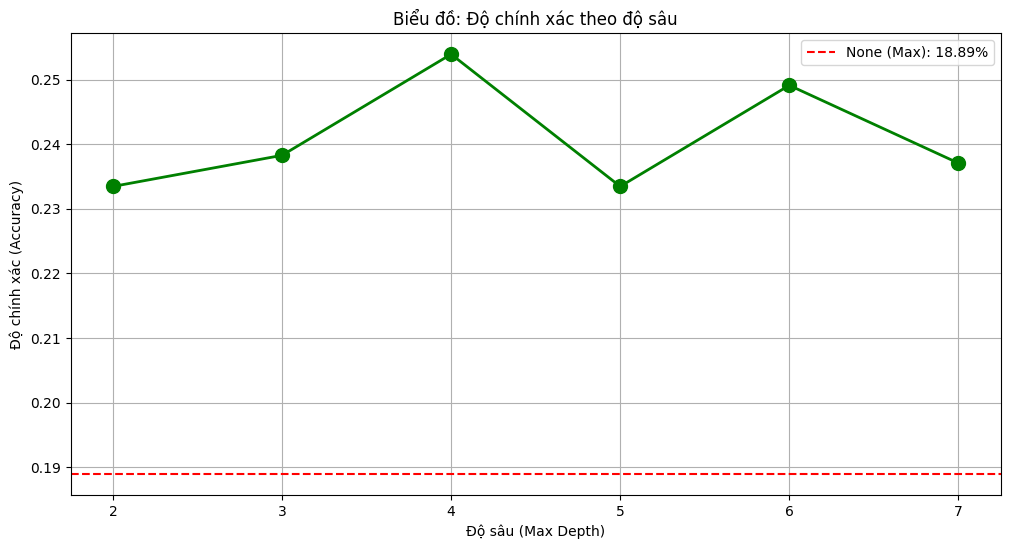

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# ======================================================
# TIÊU CHÍ 4 (NÂNG CẤP): CO GIÃN HÌNH THEO ĐỘ SÂU
# ======================================================

print(">>> BẮT ĐẦU KHẢO SÁT VÀ VẼ CÂY (CHẾ ĐỘ CO GIÃN THÔNG MINH)...")

# 1. Chuẩn bị dữ liệu (Tỷ lệ 80/20)
# (Đảm bảo bạn đã chạy ô Tải dữ liệu trước đó để có biến X, y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=42
)

depths = [2, 3, 4, 5, 6, 7, None]
results = []

for d in depths:
    # --- A. CẤU HÌNH KÍCH THƯỚC ĐỘNG (DYNAMIC SIZING) ---
    # Đây là đoạn xử lý yêu cầu của bạn:
    if d == 2:
        cur_figsize = (15, 8)   # Hình vừa phải
        cur_fontsize = 18       # Chữ rất to
    elif d == 3:
        cur_figsize = (20, 10)  # Hình to hơn xíu
        cur_fontsize = 14       # Chữ to vừa
    elif d == 4:
        cur_figsize = (30, 15)  # Hình rộng
        cur_fontsize = 11       # Chữ bình thường
    elif d is not None and d <= 6: # Depth 5, 6
        cur_figsize = (45, 20)  # Hình rất lớn
        cur_fontsize = 9        # Chữ nhỏ lại
    else: # Depth 7 hoặc None (Cây khổng lồ)
        cur_figsize = (60, 30)  # Hình cực đại
        cur_fontsize = 7        # Chữ bé xíu để không bị đè
    
    # --- B. HUẤN LUYỆN ---
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    acc = accuracy_score(y_test, clf.predict(X_test))
    depth_label = str(d) if d is not None else "None (Max)"
    results.append({'Max Depth': depth_label, 'Accuracy': acc})
    
    # --- C. VẼ CÂY ---
    print(f"\n[{depth_label}] Đang vẽ cây... (Độ chính xác: {acc:.2%})")
    
    plt.figure(figsize=cur_figsize) # Áp dụng kích thước động
    
    plot_tree(clf, 
              feature_names=X.columns, 
              class_names=[str(c) for c in clf.classes_],
              filled=True, 
              rounded=True, 
              max_depth=None, # Luôn vẽ full cây
              fontsize=cur_fontsize) # Áp dụng cỡ chữ động
    
    plt.title(f"Cây Quyết Định - Max Depth: {depth_label}", fontsize=20)
    plt.show()

# --- D. BẢNG VÀ BIỂU ĐỒ TỔNG KẾT ---
df_results = pd.DataFrame(results)
print("\n" + "="*40)
print("BẢNG KẾT QUẢ ĐỘ CHÍNH XÁC")
print("="*40)
print(df_results)

plt.figure(figsize=(12, 6))
df_plot = df_results[df_results['Max Depth'] != "None (Max)"]
plt.plot(df_plot['Max Depth'].astype(int), df_plot['Accuracy'], 
         marker='o', markersize=10, color='green', linewidth=2)

# Vẽ đường None
acc_none = df_results[df_results['Max Depth'] == "None (Max)"]['Accuracy'].values[0]
plt.axhline(y=acc_none, color='red', linestyle='--', label=f'None (Max): {acc_none:.2%}')

plt.title('Biểu đồ: Độ chính xác theo độ sâu')
plt.xlabel('Độ sâu (Max Depth)')
plt.ylabel('Độ chính xác (Accuracy)')
plt.legend()
plt.grid(True)
plt.show()